In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import probplot
import yfinance as yf
from scipy.stats import norm

# ── Ticker symbols & date range ────────────────────────────────
tickers    = ["KO", "PEP"]
start_date = '2022-07-14'
end_date   = '2023-10-09'

# ── Monte Carlo parameters ─────────────────────────────────────
NTrials = 1000   # number of simulated paths
T       = 1      # time horizon (normalised)
NSteps  = 60     # number of time steps per simulation
dt      = T / NSteps

# ── Portfolio simulation parameters ───────────────────────────
initial_cash        = 100_000
daily_interest_rate = 0.05 / 252   # 5% annual rate over 252 trading days
simulation_days     = 7            # length of the pairs trade window
num_simulations     = 1000


In [2]:
data           = yf.download(tickers, start=start_date, end=end_date)
adj_close_data = data["Close"]

KO     = adj_close_data['KO']
PEP    = adj_close_data['PEP']
spread = PEP - KO   # the spread models for mean reversion

adj_close_data.tail()


[*********************100%***********************]  2 of 2 completed


Ticker,KO,PEP
Date,,
2023-10-02,51.879852,155.043976
2023-10-03,51.318794,153.696716
2023-10-04,51.468407,154.805679
2023-10-05,48.981022,146.731339
2023-10-06,49.691708,146.905457


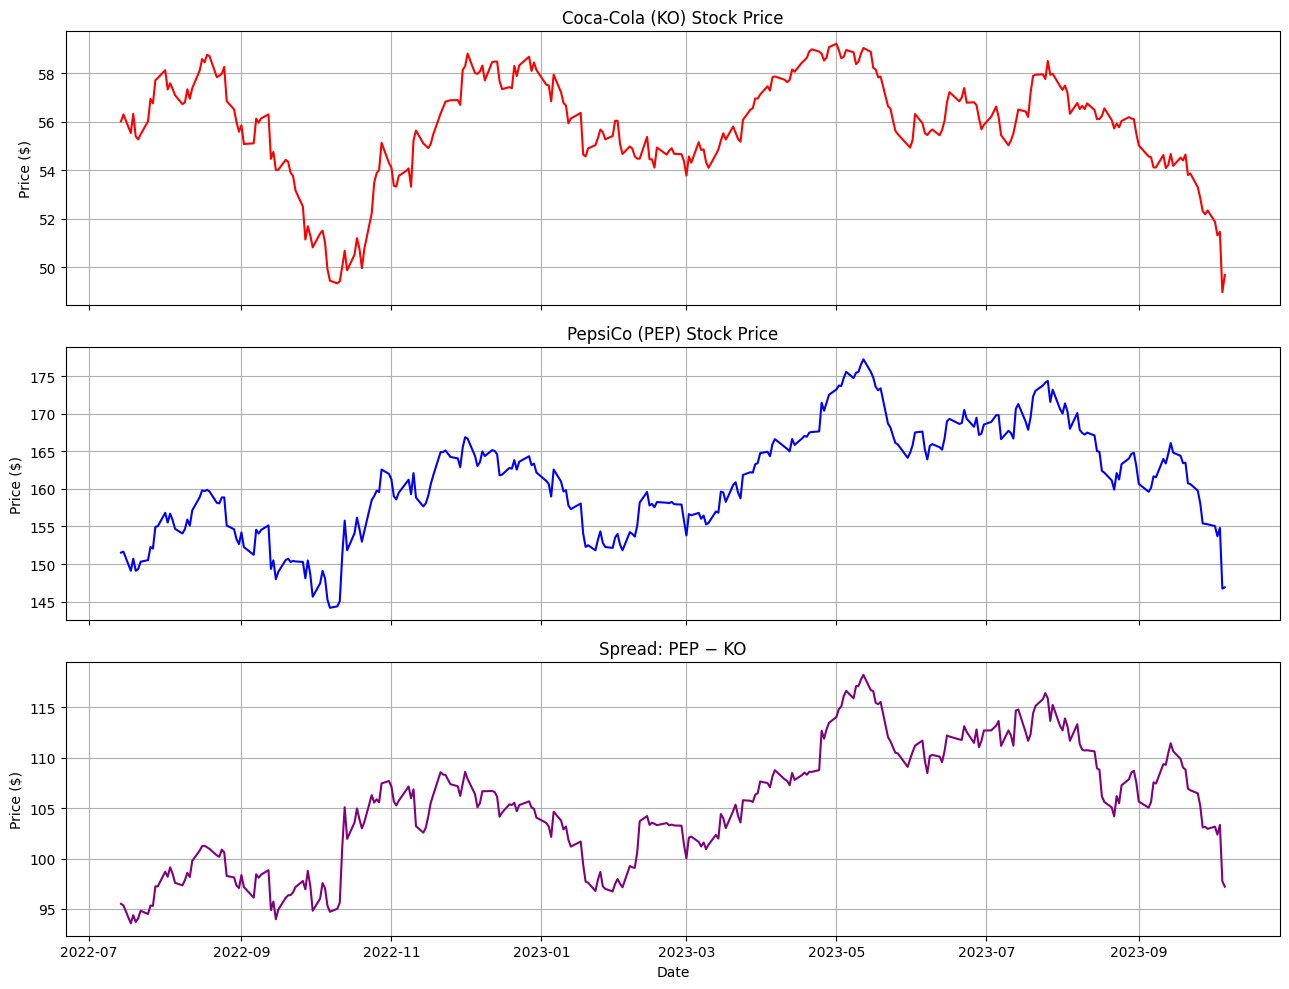

In [3]:
fig, axes = plt.subplots(3, 1, figsize=(13, 10), sharex=True)

axes[0].plot(adj_close_data.index, KO, color='red')
axes[0].set_title('Coca-Cola (KO) Stock Price')
axes[0].set_ylabel('Price ($)'); axes[0].grid(True)

axes[1].plot(adj_close_data.index, PEP, color='blue')
axes[1].set_title('PepsiCo (PEP) Stock Price')
axes[1].set_ylabel('Price ($)'); axes[1].grid(True)

axes[2].plot(adj_close_data.index, spread, color='purple')
axes[2].set_title('Spread: PEP − KO')
axes[2].set_ylabel('Price ($)'); axes[2].grid(True)

plt.xlabel('Date')
plt.tight_layout()
plt.show()


- **Histograms** show the overall shape of the return distribution
- **Q-Q plots** reveal deviations from normality, especially in the tails — important for understanding tail risk in the simulation


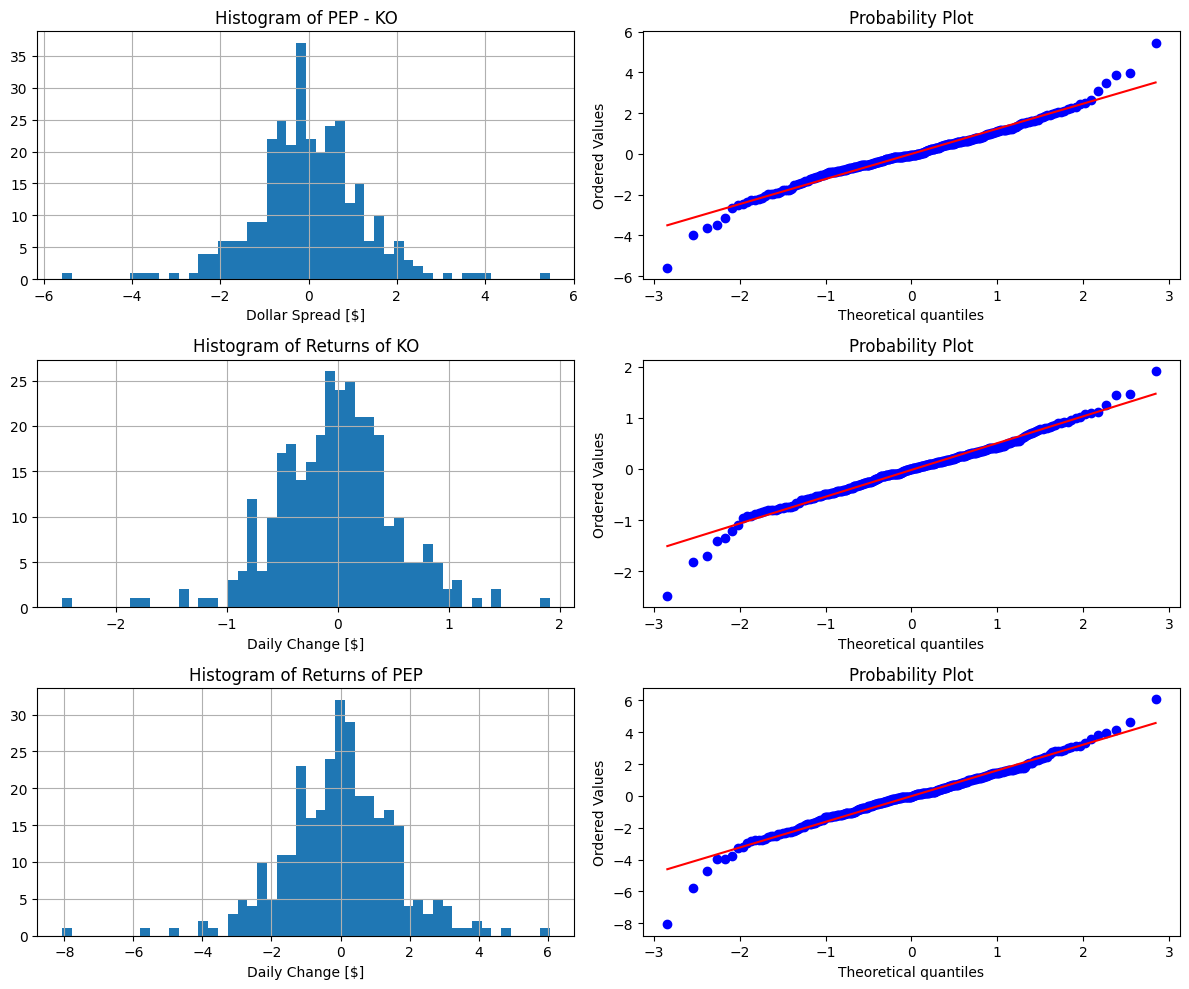

In [4]:
# Daily dollar changes (first differences)
dSpread = spread.diff().dropna()
dKO     = KO.diff().dropna()
dPEP    = PEP.diff().dropna()

# Daily percentage returns — used later for the portfolio simulation
rKO  = KO.pct_change().dropna()
rPEP = PEP.pct_change().dropna()

plt.figure(figsize=(12, 10))

plt.subplot(3, 2, 1)
plt.hist(dSpread, bins=50)
plt.title('Histogram of PEP - KO')
plt.xlabel('Dollar Spread [$]')
plt.grid(True)
plt.subplot(3, 2, 2)
probplot(dSpread, plot=plt)

plt.subplot(3, 2, 3)
plt.hist(dKO, bins=50)
plt.title('Histogram of Returns of KO')
plt.xlabel('Daily Change [$]')
plt.grid(True)
plt.subplot(3, 2, 4)
probplot(dKO, plot=plt)

plt.subplot(3, 2, 5)
plt.hist(dPEP, bins=50)
plt.title('Histogram of Returns of PEP')
plt.xlabel('Daily Change [$]')
plt.grid(True)
plt.subplot(3, 2, 6)
probplot(dPEP, plot=plt)

plt.tight_layout()
plt.show()


## Independent Monte Carlo Simulation

I simulate price paths for KO, PEP, and the spread independently using **bootstrapped (empirical) returns** — no correlation between the two stocks is imposed yet.

Each path uses inverse-transform sampling from the historical return distribution rather than assuming normality, which preserves skewness and fat tails. The discretised arithmetic random walk used is:

`X[t] = X[t-1] + μ·dt + σ·√dt·Z`

where `Z` is sampled from the empirical quantiles of the historical daily changes.


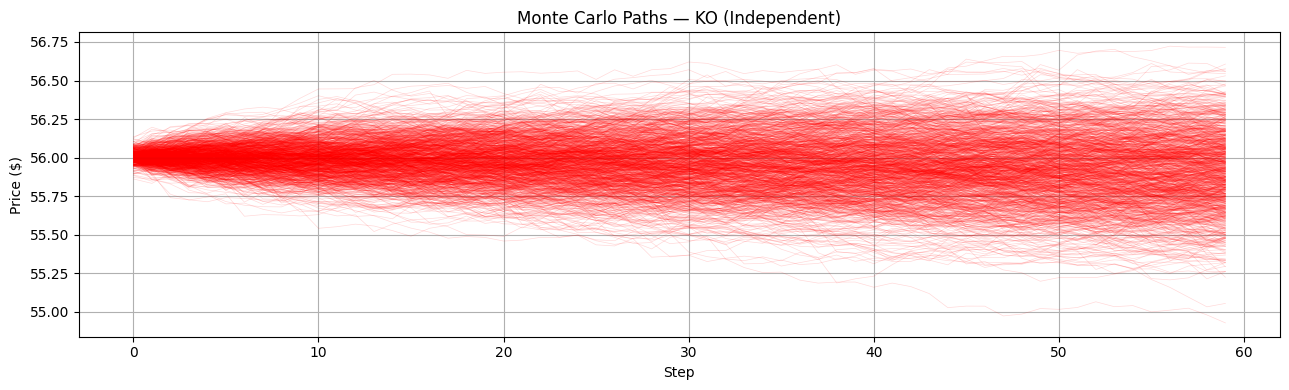

In [5]:
# ── Simulate KO ────────────────────────────────────────────────
mu_KO    = dKO.mean()
sigma_KO = dKO.std()

U   = np.random.rand(NSteps, NTrials)
Z   = np.percentile(dKO, 100 * U)   # inverse-transform sampling from empirical distribution
Xo  = KO.iloc[0]

Xko = np.cumsum(mu_KO * dt + sigma_KO * np.sqrt(dt) * Z, axis=0) + Xo

plt.figure(figsize=(13, 4))
for i in range(NTrials):
    plt.plot(Xko[:, i], alpha=0.15, linewidth=0.5, color='red')
plt.title('Monte Carlo Paths — KO (Independent)')
plt.xlabel('Step'); plt.ylabel('Price ($)'); plt.grid(True); plt.tight_layout(); plt.show()


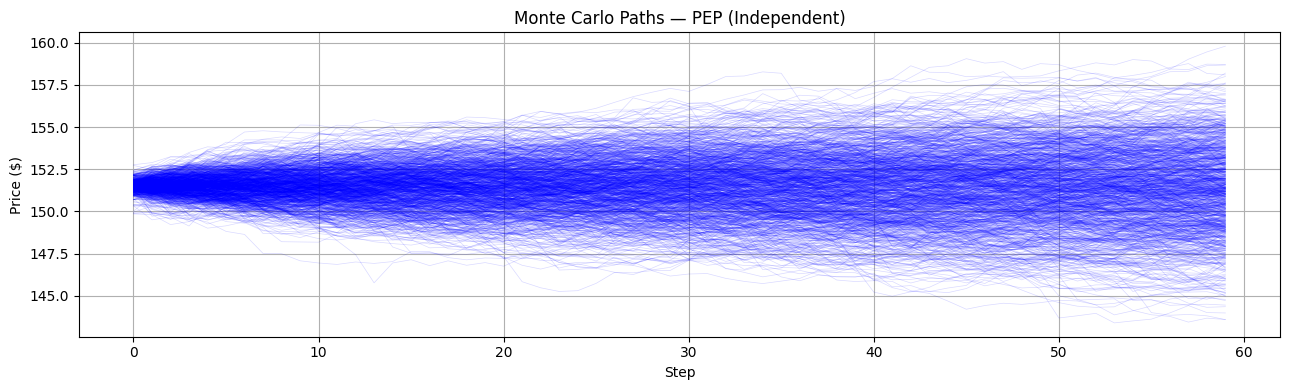

In [6]:
# ── Simulate PEP ───────────────────────────────────────────────
mu_PEP    = dPEP.mean()
sigma_PEP = dPEP.std()

U   = np.random.rand(NSteps, NTrials)
Z   = np.percentile(dPEP, 100 * U)
Xo  = PEP.iloc[0]

Xpep = np.cumsum(mu_PEP * dt + sigma_PEP * np.sqrt(dt) * Z, axis=0) + Xo

plt.figure(figsize=(13, 4))
for i in range(NTrials):
    plt.plot(Xpep[:, i], alpha=0.15, linewidth=0.5, color='blue')
plt.title('Monte Carlo Paths — PEP (Independent)')
plt.xlabel('Step'); plt.ylabel('Price ($)'); plt.grid(True); plt.tight_layout(); plt.show()


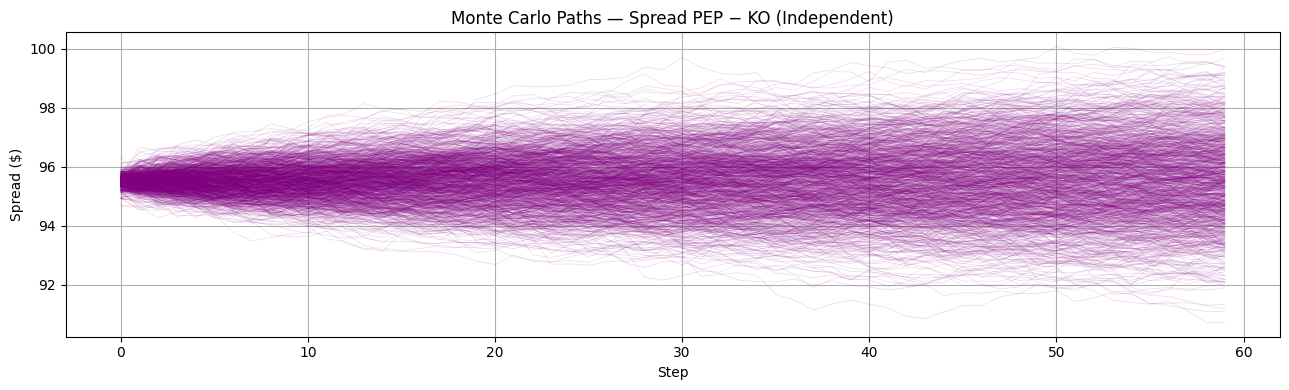

In [7]:
# ── Simulate the Spread ────────────────────────────────────────
mu_SPREAD    = dSpread.mean()
sigma_SPREAD = dSpread.std()

U   = np.random.rand(NSteps, NTrials)
Z   = np.percentile(dSpread, 100 * U)
Xo  = spread.iloc[0]

Xspread = np.cumsum(mu_SPREAD * dt + sigma_SPREAD * np.sqrt(dt) * Z, axis=0) + Xo

plt.figure(figsize=(13, 4))
for i in range(NTrials):
    plt.plot(Xspread[:, i], alpha=0.15, linewidth=0.5, color='purple')
plt.title('Monte Carlo Paths — Spread PEP − KO (Independent)')
plt.xlabel('Step'); plt.ylabel('Spread ($)'); plt.grid(True); plt.tight_layout(); plt.show()


##  Correlated Simulation via Cholesky Decomposition




In [8]:
# Draw independent uniform random numbers for each stock
u1 = np.random.rand(NSteps, NTrials)
u2 = np.random.rand(NSteps, NTrials)

# Map to empirical quantiles (inverse-transform sampling)
w1 = np.percentile(dPEP, 100 * u1)
w2 = np.percentile(dKO,  100 * u2)

# Compute correlation matrix and its Cholesky factor
C = np.corrcoef([dPEP, dKO])
L = np.linalg.cholesky(C).T   # upper-triangular Cholesky factor

# Correlate the noise vectors across all trials
z1 = np.zeros_like(w1)
z2 = np.zeros_like(w2)

for i in range(NTrials):
    zTemp    = np.column_stack((w1[:, i], w2[:, i])) @ L
    z1[:, i] = zTemp[:, 0]   # correlated PEP noise
    z2[:, i] = zTemp[:, 1]   # correlated KO noise

# Verify: the simulated correlation should be close to the historical value
sample_corr = np.corrcoef(z1[:, 0], z2[:, 0])[0, 1]
print(f"Historical correlation : {C[0,1]:.4f}")
print(f"Simulated correlation  : {sample_corr:.4f}")


Historical correlation : 0.8006
Simulated correlation  : 0.9829


##  Correlated Spread Forecast


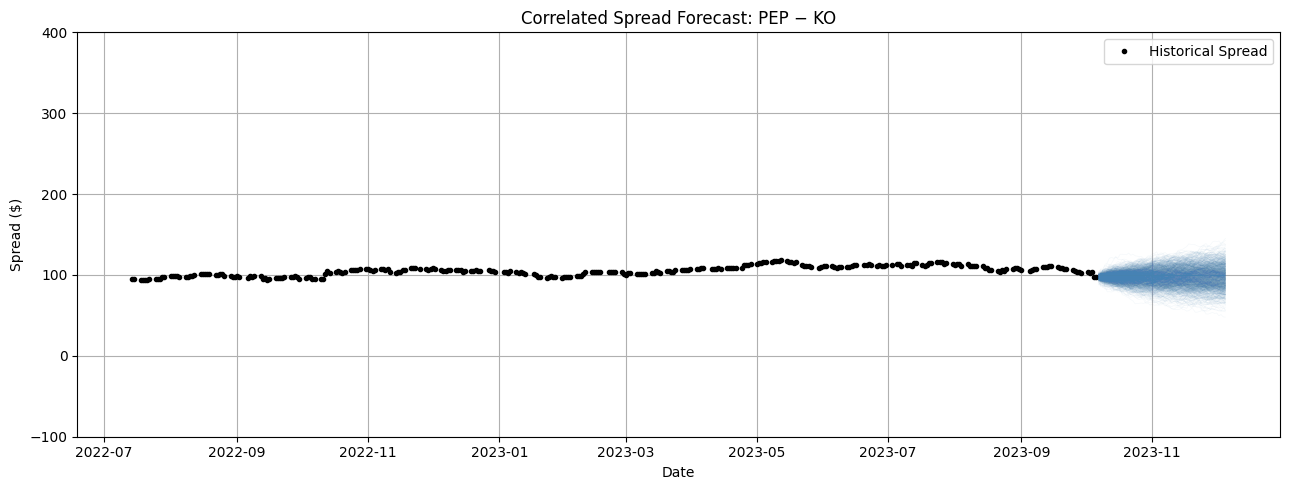

In [10]:
# Project each stock forward from its last observed price using correlated noise
# axis=0 ensures cumsum runs along time steps, keeping shape (NSteps, NTrials)
XXpepForecast    = PEP.iloc[-1] + np.cumsum(np.mean(dPEP) + np.std(dPEP) * z1, axis=0)
XXkoForecast     = KO.iloc[-1]  + np.cumsum(np.mean(dKO)  + np.std(dKO)  * z2, axis=0)
XXSpreadForecast = XXpepForecast - XXkoForecast

# Build a date axis starting the day after the last observed date
tForecast = pd.date_range(
    start=adj_close_data.index[-1] + pd.DateOffset(days=1),
    periods=NSteps
)

plt.figure(figsize=(13, 5))
plt.plot(adj_close_data.index, spread, 'ko', markersize=3, label='Historical Spread')
for i in range(NTrials):
    plt.plot(tForecast, XXSpreadForecast[:, i], alpha=0.05, linewidth=0.5, color='steelblue')
plt.ylim([-100, 400])
plt.title('Correlated Spread Forecast: PEP − KO')
plt.xlabel('Date'); plt.ylabel('Spread ($)'); plt.legend(); plt.grid(True)
plt.tight_layout(); plt.show()

## Detrending the Spread


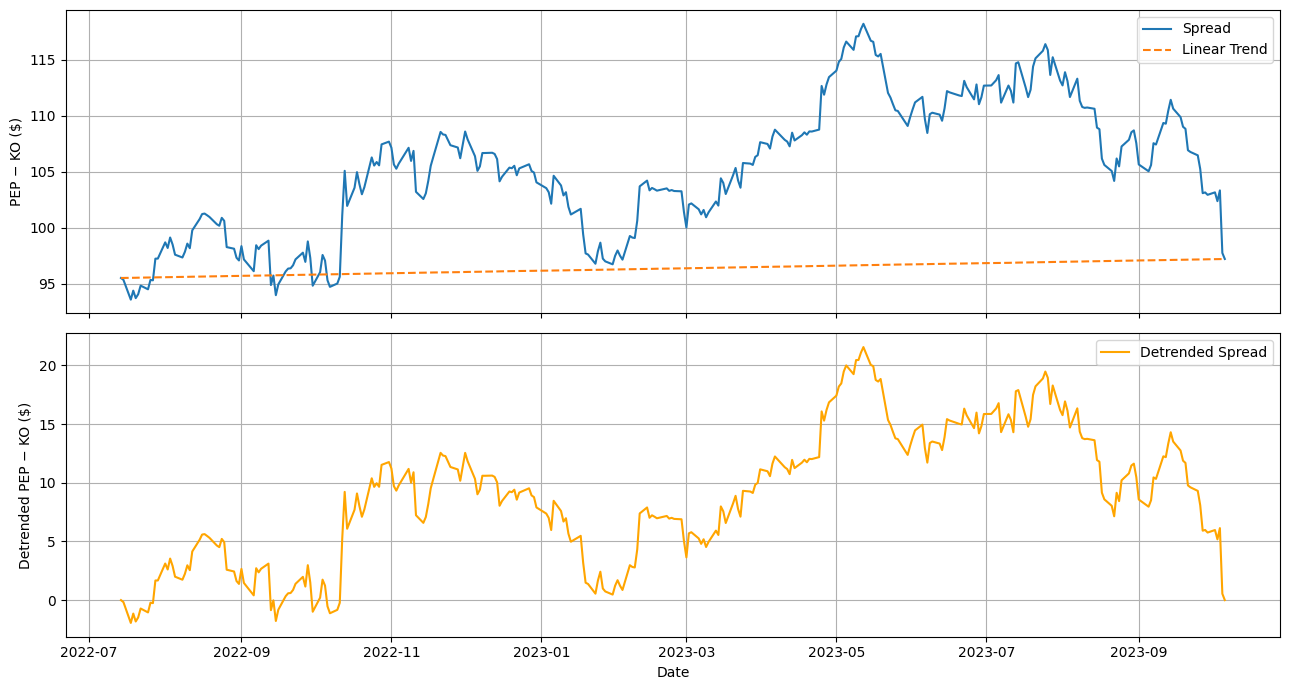

In [11]:
t      = adj_close_data.index
NSteps = len(t)

# Fit a simple linear trend through the spread
sTrend        = spread.iloc[0] + np.mean(np.diff(spread)) * np.linspace(0, NSteps - 1, NSteps)
spreadDetrend = spread.values - sTrend

fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)

axes[0].plot(t, spread.values, label='Spread')
axes[0].plot(t, sTrend, linestyle='--', label='Linear Trend')
axes[0].set_ylabel('PEP − KO ($)'); axes[0].legend(); axes[0].grid(True)

axes[1].plot(t, spreadDetrend, color='orange', label='Detrended Spread')
axes[1].set_ylabel('Detrended PEP − KO ($)'); axes[1].legend(); axes[1].grid(True)

plt.xlabel('Date'); plt.tight_layout(); plt.show()


##  Ornstein-Uhlenbeck Mean-Reversion Model


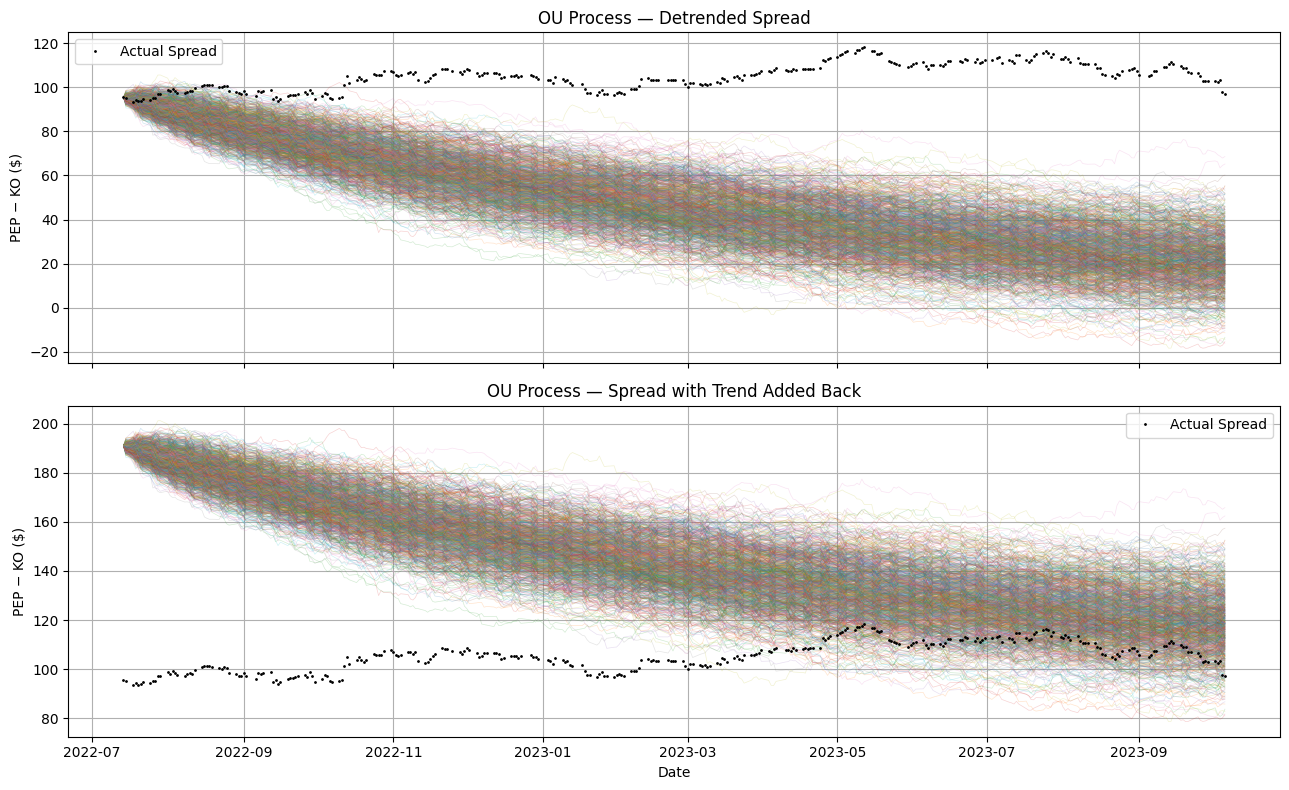

In [12]:
# OU process parameters estimated from historical data
spreadDetrend_ou = PEP - KO
mu    = np.mean(np.diff(spreadDetrend_ou))
sigma = np.std(np.diff(spreadDetrend_ou))
Xo    = spreadDetrend_ou.iloc[0]
a     = 0.005   # mean-reversion speed — tune to control how quickly spread reverts

# Standard normal noise for all steps and trials
Z = np.random.normal(0, 1, size=(NSteps, NTrials))

# Simulate the OU process step-by-step
XOU      = np.zeros((NSteps, NTrials))
XOU[0,:] = Xo

for i in range(1, NSteps):
    # OU update: drift + mean-reversion pull + random shock
    XOU[i, :] = XOU[i-1, :] + mu - a * XOU[i-1, :] + sigma * Z[i, :]

# Add the linear trend back to recover full price-level spread paths
sTrend   = spread.iloc[0] + np.mean(np.diff(spread)) * np.linspace(0, NSteps - 1, NSteps)
XOUTREND = XOU + sTrend[:, np.newaxis]

fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)

axes[0].plot(t, XOU, alpha=0.2, linewidth=0.5)
axes[0].plot(t, spreadDetrend_ou, 'ko', markersize=1, label='Actual Spread')
axes[0].set_title('OU Process — Detrended Spread')
axes[0].set_ylabel('PEP − KO ($)'); axes[0].legend(); axes[0].grid(True)

axes[1].plot(t, XOUTREND, alpha=0.2, linewidth=0.5)
axes[1].plot(t, spread, 'ko', markersize=1, label='Actual Spread')
axes[1].set_title('OU Process — Spread with Trend Added Back')
axes[1].set_ylabel('PEP − KO ($)'); axes[1].legend(); axes[1].grid(True)

plt.xlabel('Date'); plt.tight_layout(); plt.show()


## Portfolio Simulation: Long PEP / Short KO


In [13]:
# Compute daily return statistics from historical data
rKO  = KO.pct_change().dropna()
rPEP = PEP.pct_change().dropna()

coke_mean,  coke_std  = rKO.mean(),  rKO.std(ddof=1)
pepsi_mean, pepsi_std = rPEP.mean(), rPEP.std(ddof=1)

# Storage: rows = simulations, cols = trading days
portfolio_values = np.zeros((num_simulations, simulation_days))

for i in range(num_simulations):
    cash         = initial_cash
    coke_shares  = 0.0
    pepsi_shares = 0.0

    for day in range(simulation_days):
        # Sample daily returns from normal distributions fitted to historical data
        daily_return_coke  = np.random.normal(coke_mean,  coke_std)
        daily_return_pepsi = np.random.normal(pepsi_mean, pepsi_std)

        # Mark-to-market current positions
        coke_value  = coke_shares  * (1 + daily_return_coke)
        pepsi_value = pepsi_shares * (1 + daily_return_pepsi)
        total_value = cash + coke_value + pepsi_value

        # Cash earns the risk-free rate
        cash *= (1 + daily_interest_rate)

        # Rebalance to equal-notional long/short
        coke_shares  = -total_value / 2   # short KO
        pepsi_shares =  total_value / 2   # long PEP

        portfolio_values[i, day] = total_value


=== Portfolio Simulation Summary ===
  Mean Final Value:        $  100,174.08
  Std Dev of Final Value:  $      704.14
  5th Percentile  (VaR):   $   99,022.84
  95th Percentile:         $  101,278.25


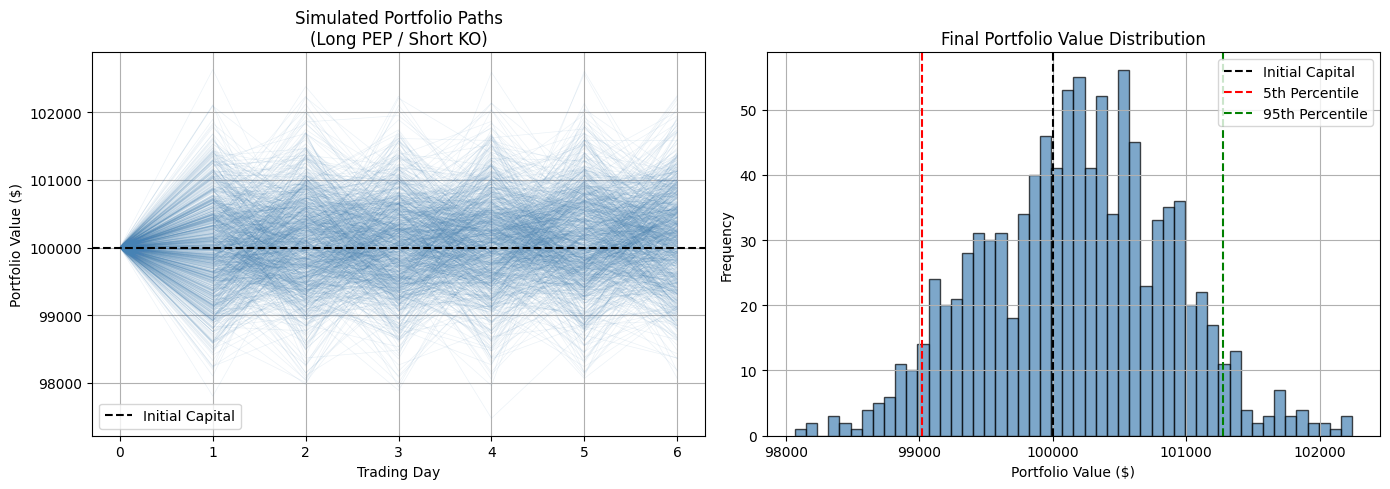

In [14]:
# ── Risk metrics ───────────────────────────────────────────────
final_values = portfolio_values[:, -1]

print("=== Portfolio Simulation Summary ===")
print(f"  Mean Final Value:        ${np.mean(final_values):>12,.2f}")
print(f"  Std Dev of Final Value:  ${np.std(final_values):>12,.2f}")
print(f"  5th Percentile  (VaR):   ${np.percentile(final_values,  5):>12,.2f}")
print(f"  95th Percentile:         ${np.percentile(final_values, 95):>12,.2f}")

# ── Plot paths and final distribution ─────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(portfolio_values.T, alpha=0.1, linewidth=0.5, color='steelblue')
axes[0].axhline(initial_cash, color='black', linestyle='--', label='Initial Capital')
axes[0].set_title('Simulated Portfolio Paths\n(Long PEP / Short KO)')
axes[0].set_xlabel('Trading Day'); axes[0].set_ylabel('Portfolio Value ($)')
axes[0].legend(); axes[0].grid(True)

axes[1].hist(final_values, bins=50, edgecolor='black', alpha=0.7, color='steelblue')
axes[1].axvline(initial_cash,                        color='black', linestyle='--', label='Initial Capital')
axes[1].axvline(np.percentile(final_values,  5),     color='red',   linestyle='--', label='5th Percentile')
axes[1].axvline(np.percentile(final_values, 95),     color='green', linestyle='--', label='95th Percentile')
axes[1].set_title('Final Portfolio Value Distribution')
axes[1].set_xlabel('Portfolio Value ($)'); axes[1].set_ylabel('Frequency')
axes[1].legend(); axes[1].grid(True)

plt.tight_layout()
plt.show()
